# Sprint 01 — US 1.1 : Analyse exploratoire (sur bronze)

Exploration et statistiques descriptives sur la couche `bronze` (médaillon), pour les
trois sources : **incidents**, **télémétrie**, **référentiel**. La logique vit dans
`src/indusense/data/` ; ce notebook **orchestre** les pipelines et **visualise** les
résultats.

> **Prérequis** : exécuter d'abord `00_acquisition.ipynb` (couche `bronze` alimentée).

## Analyse des incidents

Traitement des relevés d'incidents via un pipeline reproductible et tracé
(`indusense-incidents`), lisant `bronze.incident`. À chaque exécution, il produit dans
`artifacts/analyses/incidents/AAAAMMJJHHMM/` :

- un **dataset anonymisé + enrichi** (Parquet **et** CSV, versionné) ;
- **12 graphes SVG** annotés (distributions, histogrammes par signal/machine, corrélations) ;
- un **journal de runs** (`runs.json` / `runs.md`) et une note **`METHODOLOGIE.md`**.

Les cellules ci-dessous rejouent les étapes clés (cf. `src/indusense/data/incidents.py`).

In [1]:
from indusense.data.incidents import load_incidents

incidents_raw = load_incidents()
print("dimensions :", incidents_raw.shape)
incidents_raw.isna().sum()

dimensions : (1245, 18)


incident_id               0
date                      0
time                      0
operator_name             0
machine_id                0
severity                  0
operator_badge            0
comment                   0
shift                     0
type_surchauffe           0
type_baisse_pression      0
type_vibration            0
type_bruit_mecanique      0
type_surconsommation      0
type_blocage_mecanique    0
type_alarme_capteur       0
type_arret_urgence        0
type_defaut_qualite       0
dtype: int64

### 1. Anonymisation des opérateurs (minimisation RGPD)

`operator_name` et `operator_badge` sont des identifiants directs (DCP), **non
nécessaires** à l'analyse machine → **supprimés** (anonymisation irréversible).
`comment` est conservé (saisie guidée non-DCP). Justification complète :
`artifacts/analyses/incidents/METHODOLOGIE.md`.

In [2]:
from indusense.data.anonymize import anonymize_operators

incidents_anon = anonymize_operators(incidents_raw)
print("colonnes supprimées :", set(incidents_raw.columns) - set(incidents_anon.columns))
print("dimensions après anonymisation :", incidents_anon.shape)

colonnes supprimées : {'operator_name', 'operator_badge'}
dimensions après anonymisation : (1245, 16)


### 2. Enrichissement & indice de confiance du signalement

On dérive le **signal dominant**, des axes temporels (jour / semaine ISO / weekday)
et un **indice de confiance par incident** (cohérence des flags + présence du
commentaire + validité machine/sévérité), borné dans [0, 1].

In [3]:
from indusense.data.incidents import compute_confidence, enrich

incidents = compute_confidence(enrich(incidents_anon))
display(incidents["signal"].value_counts())
incidents["confidence"].describe()

signal
type_alarme_capteur       212
type_bruit_mecanique      206
type_defaut_qualite       180
type_vibration            178
type_baisse_pression      165
type_surconsommation      149
type_surchauffe           128
multiple                   15
type_blocage_mecanique      8
type_arret_urgence          4
Name: count, dtype: int64

count    1245.000000
mean        0.997590
std         0.021829
min         0.800000
25%         1.000000
50%         1.000000
75%         1.000000
max         1.000000
Name: confidence, dtype: float64

### 3. Exécution du pipeline complet (dataset versionné + graphes + journal)

`run_ingestion()` enchaîne chargement → anonymisation → enrichissement → confiance,
puis écrit le Parquet, génère les 8 SVG et met à jour le journal + la méthodologie.

In [4]:
from indusense.data import incidents as ing

meta = ing.run_ingestion()
print(f"Run {meta['run_id']}")
print(
    f"  lignes={meta['n_lignes']} colonnes={meta['n_colonnes']} "
    f"machines={meta['machines_uniques']} NaN={meta['n_nan_total']} "
    f"confiance_moy={meta['confidence_moyenne']}"
)
cs = meta['coherence_shift']
print(f"  plages 3x8 valides : {cs['partition_3x8']} | incohérences : {cs['n_incoherents']}")
sev = meta['controle_severite']
print(f"  sévérité [{sev['min']},{sev['max']}] règle 1-5 : {sev['regle_1_5_respectee']} | niveaux absents : {sev['niveaux_absents']}")
tf = meta['controle_type_flags']
print(f"  flags type_ binaires : {tf['flags_binaires']} | lignes sans signal : {tf['n_lignes_sans_signal']}")
print("  figures :", ", ".join(meta["figures"]))

Run 202606221527
  lignes=1245 colonnes=27 machines=15 NaN=0 confiance_moy=0.998
  plages 3x8 valides : True | incohérences : 0
  sévérité [2,5] règle 1-5 : True | niveaux absents : [1]
  flags type_ binaires : True | lignes sans signal : 0
  figures : 01_incidents_par_jour.svg, 02_incidents_par_semaine.svg, 03_incidents_par_shift.svg, 04_incidents_par_signal.svg, 05_incidents_par_machine.svg, 06_severite_par_machine.svg, 07_machine_x_type.svg, 08_indice_confiance.svg, 09_correlation_pearson.svg, 10_correlation_spearman.svg, 11_severite_par_type.svg, 12_contingence_type_severite.svg


### 4. Visualisation des graphes (les 12 figures du dernier run)

Chaque SVG embarque son **numéro**, son titre et une légende explicative. Les figures
sont **ordonnées selon le fil de l'analyse** :

1. **Cadrage temporel** (1–3) — incidents par jour, par semaine (ISO), par shift.
2. **Typologie des pannes** (4) — incidents par signal (+ confiance moyenne).
3. **Étude par machine** (5–7) — incidents par machine, sévérité moyenne par machine,
   profil machine × type de panne.
4. **Qualité du signalement** (8) — distribution de l'indice de confiance.
5. **Corrélations entre signaux** (9–10) — *Pearson* (linéaire) vs *Spearman* (rangs).
6. **Sévérité ↔ type** (11–12) — sévérité moyenne par type, contingence type × sévérité.


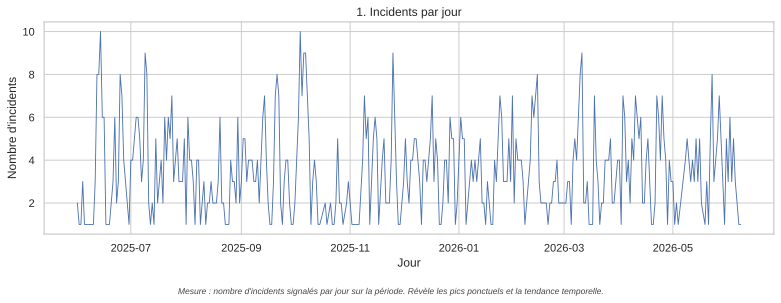

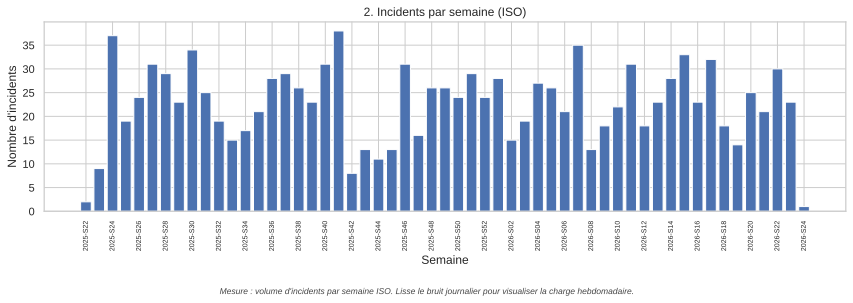

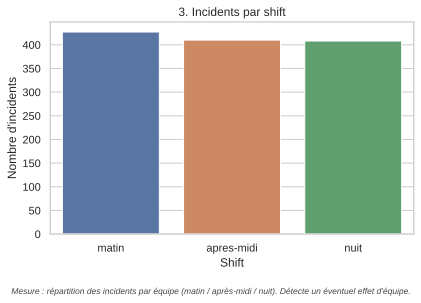

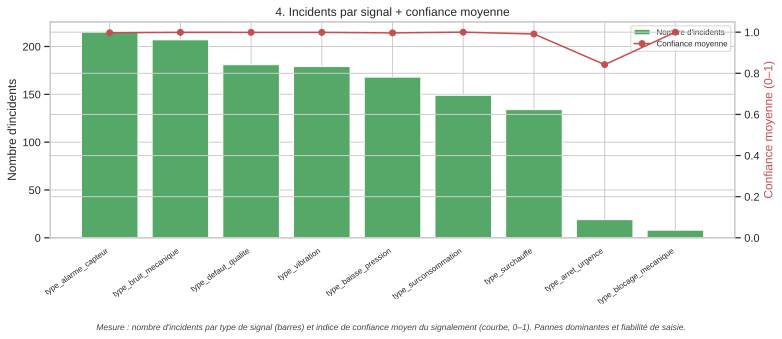

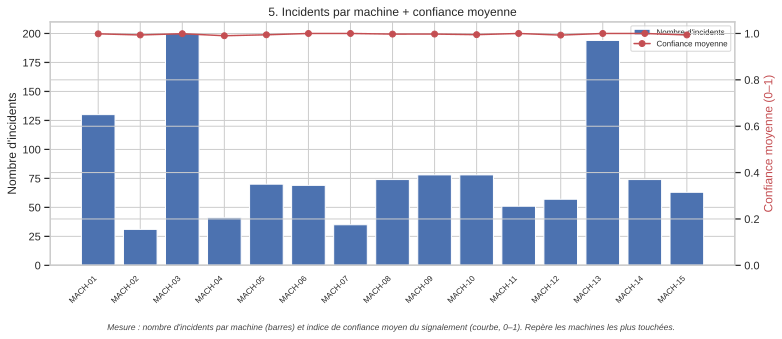

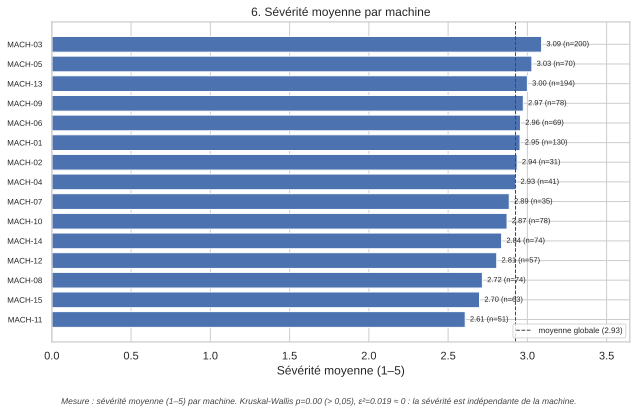

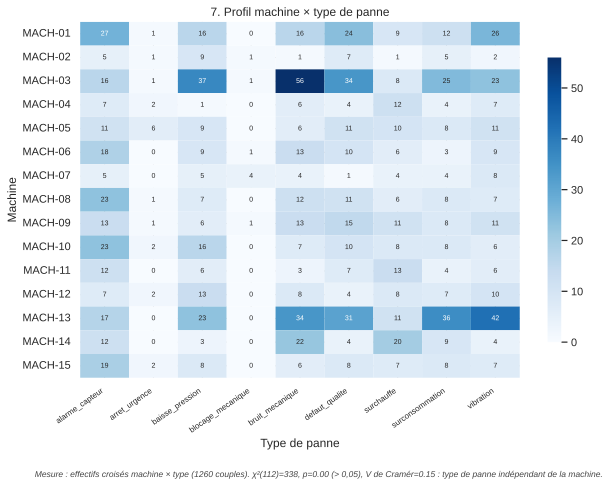

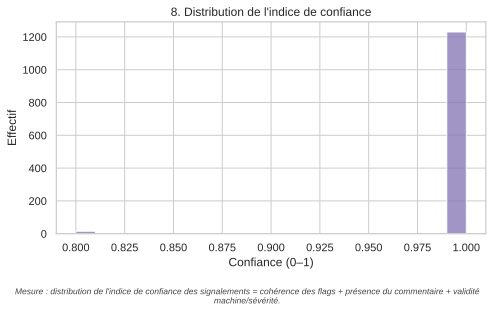

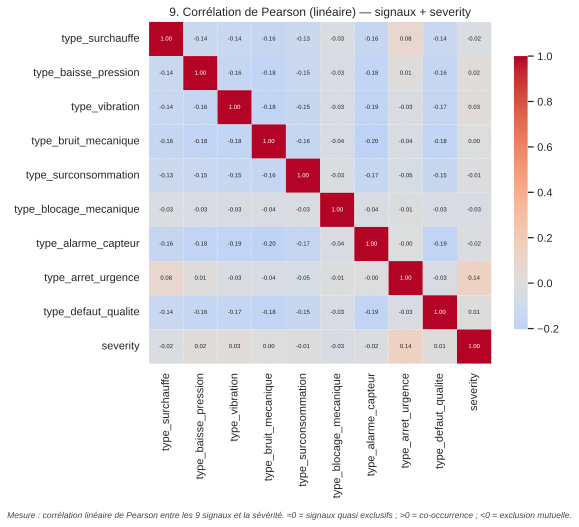

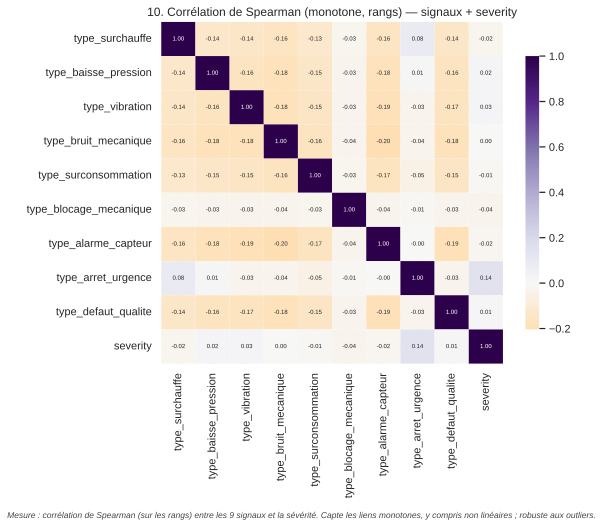

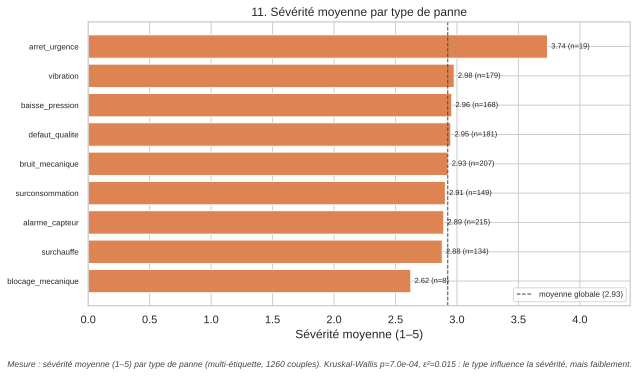

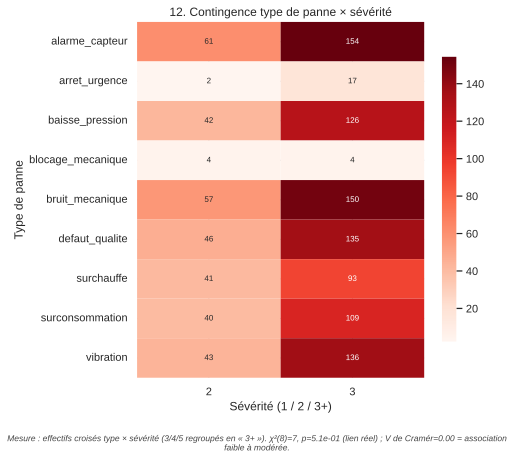

In [5]:
from IPython.display import SVG, display

from indusense import config

run_dir = sorted(p for p in config.ANALYSE_INCIDENTS_DIR.glob("2*") if p.is_dir())[-1]
# Fichiers préfixés NN_ : le tri alphabétique = l'ordre d'analyse.
for fig_path in sorted((run_dir / "figures").glob("*.svg")):
    display(SVG(filename=str(fig_path)))


### 5. Contrôle : relation entre le commentaire et les flags

`comment` est une **saisie guidée**. On vérifie sa correspondance avec les flags `type_*` :

- **Correspondance déterministe** : 1 seul commentaire distinct par signal, **aucune
  contradiction** (0 commentaire ne pointe vers plusieurs signaux). Bonne qualité de saisie.
- Cas particulier : **`type_arret_urgence` n'apparaît jamais seul** — c'est un marqueur
  d'escalade, encodé dans le commentaire par « … **+ arrêt ligne** ».
- Seul écart : 59 commentaires manquants (NaN), répartis aléatoirement sur les signaux.

➡️ **Conséquence** : le commentaire est une **redondance documentaire** des flags (label
lisible). Précieux pour la **validation croisée / l'audit**, mais **à exclure des features
ML** (colinéarité parfaite + risque de *data leakage* : le commentaire *est* l'étiquette
de la panne).

In [6]:
# 1) Correspondance signal -> commentaire (incidents mono-signal)
mono = incidents[incidents["n_signals"] == 1]
recap = (
    mono.groupby("signal")["comment"].agg(
        n="size",
        commentaires_distincts=lambda s: s.nunique(dropna=True),
        nan=lambda s: int(s.isna().sum()),
        exemple=lambda s: s.dropna().iloc[0] if s.notna().any() else None,
    )
)
display(recap)

# 2) Cohérence : un commentaire pointe-t-il vers plusieurs signaux ?
amb = mono.dropna(subset=["comment"]).groupby("comment")["signal"].nunique()
print("Commentaires liés à plusieurs signaux :", int((amb > 1).sum()), "/", amb.shape[0])

# 3) type_arret_urgence : jamais seul (marqueur d'escalade "+ arrêt ligne")
print(
    "arret_urgence — total:", int(incidents["type_arret_urgence"].sum()),
    "| en mono-signal:",
    int(incidents[(incidents.type_arret_urgence == 1) & (incidents.n_signals == 1)].shape[0]),
)

,n,commentaires_distincts,nan,exemple
signal,,,,
type_alarme_capteur,212,5,0,défaut capteur confirmé
type_arret_urgence,4,3,0,arrêt d'urgence déclenché par opérateur
type_baisse_pression,165,5,0,micro-fuite / baisse pression
type_blocage_mecanique,8,3,0,pièce bloquée convoyeur
type_bruit_mecanique,206,4,0,bruit mécanique anormal
type_defaut_qualite,180,5,0,non-conformité dimensionnelle
type_surchauffe,128,5,0,chauffe anormale
type_surconsommation,149,5,0,surconsommation électrique
type_vibration,178,5,0,vibrations excessives détectées


Commentaires liés à plusieurs signaux : 0 / 40
arret_urgence — total: 19 | en mono-signal: 4


### 6. Corrélation entre sévérité et type de panne

La sévérité est **ordinale** (1–5) et le type de panne **nominal** (multi-étiquette) :
Pearson/Spearman ne s'appliquent pas. On utilise les tests adaptés (cf. `METHODOLOGIE.md`) :
**χ² + V de Cramér** (force du lien entre deux variables catégorielles) et
**Kruskal-Wallis + ε²** (la sévérité varie-t-elle selon le type ?).

➡️ **Conclusion** : association **statistiquement significative mais faible à modérée**
(V de Cramér ≈ 0,24). Elle est portée par quelques types extrêmes — `arret_urgence`
(quasi toujours critique), puis `surchauffe` / `blocage_mecanique` — alors que la majorité
des types se concentrent dans une sévérité basse et homogène (≈ 1,5). **Le type seul ne
suffit donc pas à prédire la sévérité** : les variables de télémétrie resteront nécessaires.

Voir les figures *Sévérité moyenne par type* et *Contingence type × sévérité* ci-dessus (§4).

In [7]:
assoc = ing.severity_type_association(incidents)

print(f"Couples (incident x type) : {assoc['n_couples']}")
print(
    f"Chi2({assoc['dof']}) = {assoc['chi2']:.1f}  p = {assoc['p_chi2']:.2e}"
    f"  |  V de Cramer = {assoc['cramers_v']:.3f}"
    f"  (cellules exp.<5 : {assoc['cellules_exp_faibles']})"
)
print(
    f"Kruskal-Wallis H = {assoc['kruskal_H']:.1f}  p = {assoc['p_kruskal']:.2e}"
    f"  |  epsilon^2 = {assoc['epsilon2']:.3f}"
)

# Sévérité moyenne par type (du plus grave au moins grave)
assoc['sev_par_type'].round(3)

Couples (incident x type) : 1260


Chi2(8) = 7.2  p = 5.11e-01  |  V de Cramer = 0.000  (cellules exp.<5 : 1)
Kruskal-Wallis H = 27.0  p = 6.96e-04  |  epsilon^2 = 0.015


,count,mean,std
type_panne,,,
arret_urgence,19,3.737,0.733
vibration,179,2.978,0.742
baisse_pression,168,2.958,0.721
defaut_qualite,181,2.950,0.732
bruit_mecanique,207,2.928,0.730
surconsommation,149,2.906,0.701
alarme_capteur,215,2.893,0.699
surchauffe,134,2.881,0.736
blocage_mecanique,8,2.625,0.744


### 7. Étude statistique par machine

On décline l'analyse sur la dimension **machine** (`machine_association`, cf.
`METHODOLOGIE.md`) : **Kruskal-Wallis** (la sévérité dépend-elle de la machine ?) et
**χ² + V de Cramér** (le type de panne dépend-il de la machine ?).

➡️ **Conclusion** : ni la sévérité (Kruskal **p ≈ 0,60**), ni le type de panne (χ²
**p ≈ 0,67**, V de Cramér ≈ **0**) ne dépendent de la machine. Le parc est **homogène** —
aucune machine ne se distingue par un profil de pannes ou une gravité particulière.
Voir les figures *6. Sévérité moyenne par machine* et *7. Profil machine × type* (§4).


In [8]:
m_assoc = ing.machine_association(incidents)

print(f"Machines : {m_assoc['n_machines']} | couples (incident x type) : {m_assoc['n_couples']}")
print(
    f"Kruskal-Wallis severite~machine : H={m_assoc['kruskal_H']:.1f}"
    f"  p={m_assoc['p_kruskal']:.2f}  epsilon^2={m_assoc['epsilon2']:.3f}"
)
print(
    f"Chi2 machine x type : chi2={m_assoc['chi2']:.0f} (dof={m_assoc['dof']})"
    f"  p={m_assoc['p_chi2']:.2f}  V de Cramer={m_assoc['cramers_v']:.3f}"
    f"  (cellules exp.<5 : {m_assoc['cellules_exp_faibles']})"
)

# Sévérité moyenne par machine (du plus grave au moins grave)
m_assoc['sev_par_machine'].round(3)

Machines : 15 | couples (incident x type) : 1260
Kruskal-Wallis severite~machine : H=37.2  p=0.00  epsilon^2=0.019
Chi2 machine x type : chi2=338 (dof=112)  p=0.00  V de Cramer=0.150  (cellules exp.<5 : 40)


,count,mean,std
machine_id,,,
MACH-03,200,3.090,0.778
MACH-05,70,3.029,0.851
MACH-13,194,3.000,0.611
MACH-09,78,2.974,0.980
MACH-06,69,2.957,0.775
MACH-01,130,2.954,0.633
MACH-02,31,2.935,0.512
MACH-04,41,2.927,0.755
MACH-07,35,2.886,0.631


### Livrables produits

| Livrable | Emplacement |
|---|---|
| Dataset anonymisé + enrichi (Parquet) | `artifacts/analyses/incidents/<run>/incidents_anonymized.parquet` |
| 12 graphes SVG annotés | `artifacts/analyses/incidents/<run>/figures/` |
| Métadonnées du run | `artifacts/analyses/incidents/<run>/run_metadata.json` |
| Journal des runs | `artifacts/analyses/incidents/runs.json` · `runs.md` |
| Méthodologie (RGPD + indice de confiance) | `artifacts/analyses/incidents/METHODOLOGIE.md` |

▶️ Reproductible en une commande : `uv run indusense-incidents`.

## Analyse de la télémétrie

Second jeu de données : `telemetry.csv` (relevés capteurs **horaires** : température,
pression, tension, rotation, pièces produites). Pipeline parallèle aux incidents
(`indusense-telemetry`), lisant `bronze.telemetry` : vérification RGPD → dédoublonnage →
analyse statistique. Artefacts versionnés sous `artifacts/analyses/telemetry/`.

### 1. Anonymisation & dédoublonnage
- **Anonymisation : non requise** — aucune donnée personnelle (mesures capteurs +
  `machine_id`, identifiant d'**équipement**). Vérifié par `check_no_personal_data`.
- **Dédoublonnage** : clé d'unicité `(machine_id, timestamp)`, conservation de la 1re
  occurrence (idempotent). Doublons retirés et NaN restants sont reportés au journal du
  run (le contenu varie selon la version des données).


In [9]:
from indusense.data import telemetry as tel_an

meta_tel = tel_an.run_analysis()
print(f"Run {meta_tel['run_id']}")
print(
    f"  lignes={meta_tel['n_lignes']} machines={meta_tel['machines_uniques']}"
    f"  doublons_retires={meta_tel['n_doublons_supprimes']} NaN={meta_tel['n_nan_total']}"
    f"  outliers={meta_tel['n_outliers_total']}"
)
print(f"  anonymisation requise : {meta_tel['anonymisation_requise']}")
print(f"  periode : {meta_tel['periode_debut']} -> {meta_tel['periode_fin']}")


Run 202606221527
  lignes=134280 machines=15  doublons_retires=1346 NaN=2812  outliers=3266
  anonymisation requise : False
  periode : 2025-06-01 00:00:00 -> 2026-06-08 23:00:00


### 2. Visualisation (9 figures, ordonnées par usage)

Vue d'ensemble (1–2) → comparaison par machine (3–4) → corrélations (5–6) →
profils temporels (7–8) → lien capteurs ↔ production (9). Fichiers préfixés `NN_`.


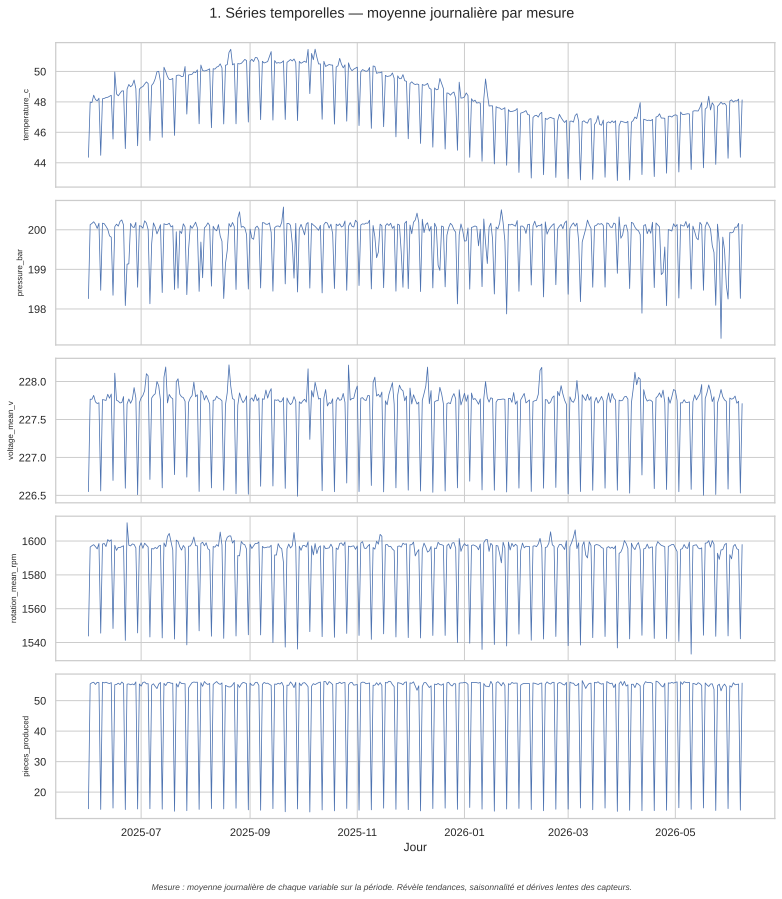

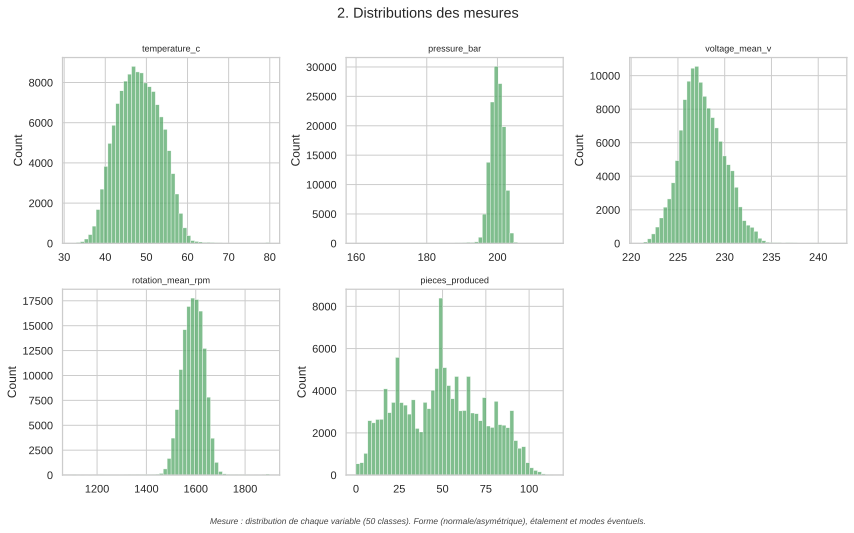

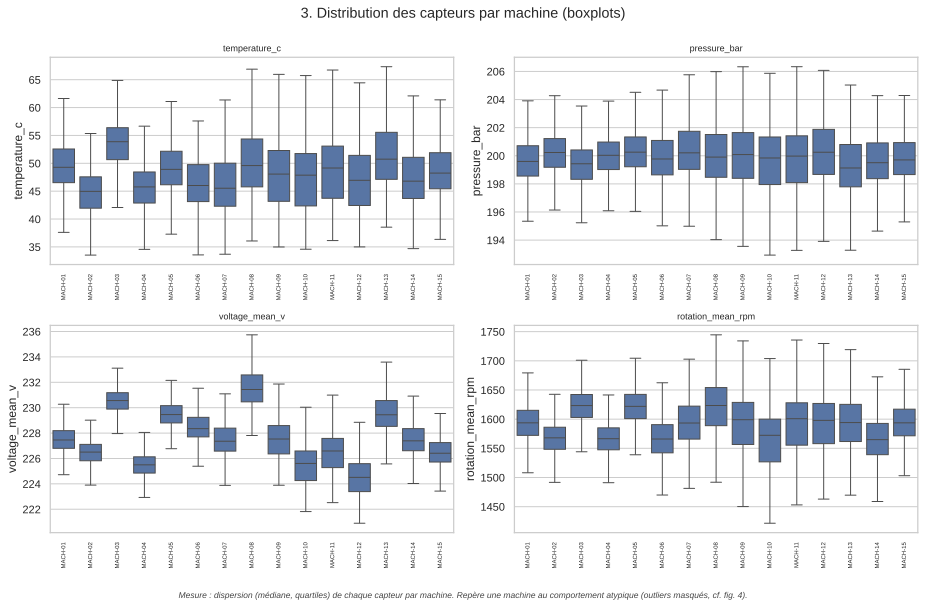

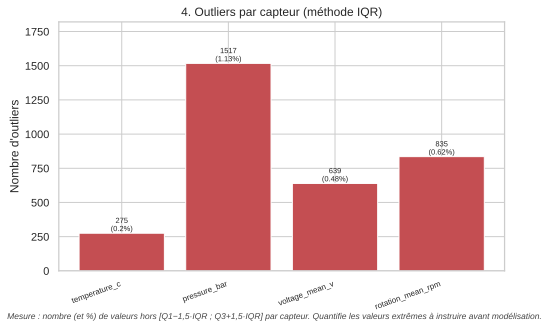

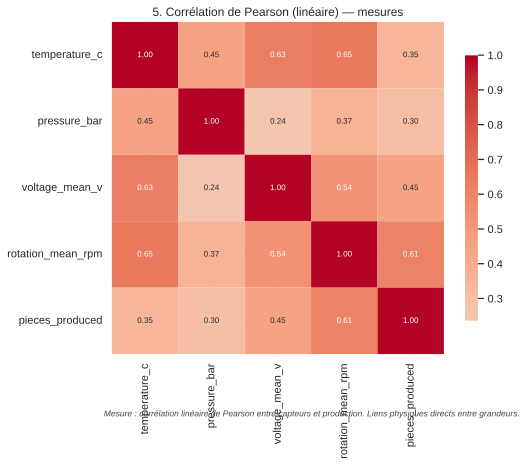

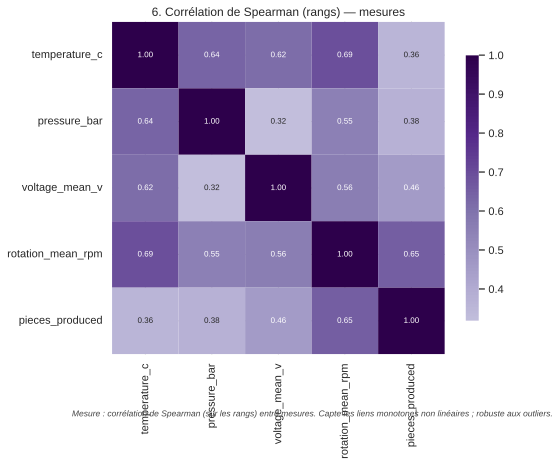

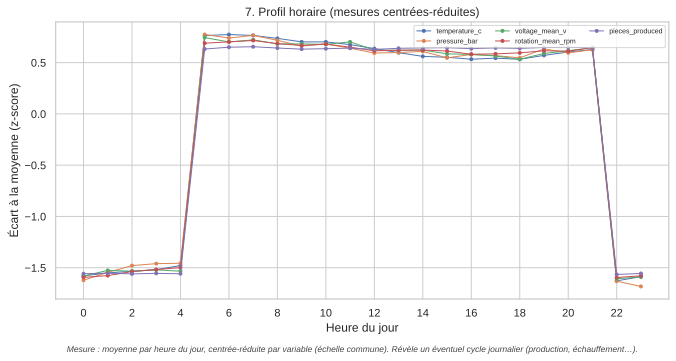

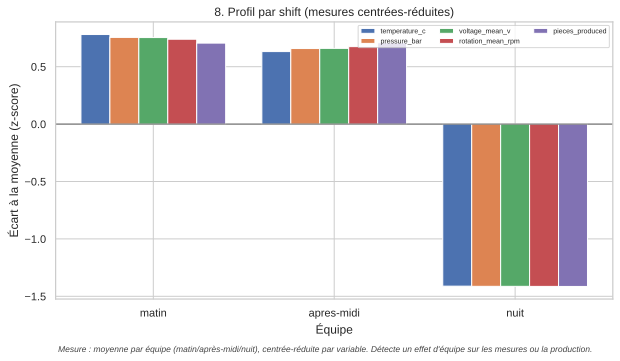

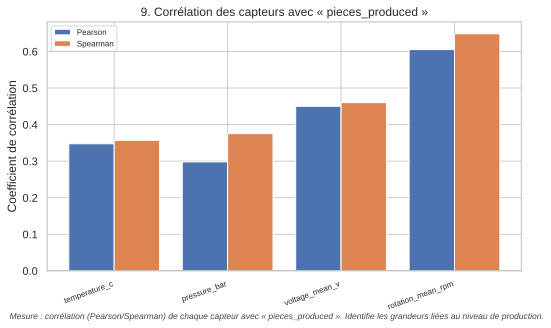

In [10]:
from IPython.display import SVG, display

from indusense import config

tel_run = sorted(p for p in config.ANALYSE_TELEMETRY_DIR.glob("2*") if p.is_dir())[-1]
for fig_path in sorted((tel_run / "figures").glob("*.svg")):
    display(SVG(filename=str(fig_path)))


### 3. Statistiques descriptives, outliers et corrélations


In [11]:
df_tel = tel_an.enrich(tel_an.deduplicate(tel_an.load_telemetry())[0])
stats = tel_an.descriptive_stats(df_tel)
display(stats['global'].round(2))
print('Outliers par capteur (méthode IQR) :')
display(tel_an.detect_outliers(df_tel))
print('Corrélation de Pearson (capteurs + production) :')
tel_an.correlations(df_tel)['pearson'].round(2)


,count,mean,std,min,25%,50%,75%,max
temperature_c,133398.0,48.18,5.25,32.00,44.25,48.05,52.06,80.00
pressure_bar,133298.0,199.77,2.37,159.98,198.57,199.87,201.19,215.81
voltage_mean_v,134280.0,227.63,2.30,220.90,226.03,227.42,229.15,242.00
rotation_mean_rpm,133332.0,1589.21,45.95,1100.00,1559.01,1590.38,1620.85,1900.00
pieces_produced,134280.0,49.54,24.57,0.00,28.00,49.00,68.00,114.00


Outliers par capteur (méthode IQR) :


,borne_basse,borne_haute,n_outliers,pct
temperature_c,32.53,63.77,275,0.20
pressure_bar,194.65,205.11,1517,1.13
voltage_mean_v,221.35,233.83,639,0.48
rotation_mean_rpm,1466.25,1713.61,835,0.62


Corrélation de Pearson (capteurs + production) :


,temperature_c,pressure_bar,voltage_mean_v,rotation_mean_rpm,pieces_produced
temperature_c,1.00,0.45,0.63,0.65,0.35
pressure_bar,0.45,1.00,0.24,0.37,0.30
voltage_mean_v,0.63,0.24,1.00,0.54,0.45
rotation_mean_rpm,0.65,0.37,0.54,1.00,0.61
pieces_produced,0.35,0.30,0.45,0.61,1.00


➡️ **Conclusions**

- **Qualité** : le dédoublonnage retire **1 346** doublons de clé ; il subsiste des **NaN**
  sur 3 capteurs (température, pression, rotation) et **~0,2–1,1 %** d'outliers (IQR, la
  pression la plus touchée). NaN et outliers sont **signalés, non corrigés** ici (→ silver).
- **Liens inter-capteurs** : les 4 capteurs restent **positivement corrélés** (≈ 0,24–0,65),
  décrivant un même **régime d'activité machine** (corrélations les plus fortes autour de la rotation).
- **Production** : la **vitesse de rotation** est le meilleur proxy de `pieces_produced`
  (r ≈ 0,61), devant tension/pression. Pearson ≈ Spearman → liens quasi linéaires.
- Ces signaux sont **exploitables** pour la maintenance prédictive (modélisation silver/gold).


## Analyse du référentiel

Troisième source : le **référentiel** (dump SQL fourni `data/raw/machine.sql`, tables
`machine` et `maintenance`), chargé dans `bronze` par `indusense-ingest --migrate`. Le
pipeline `indusense-referentiel` lit la **couche bronze** (médaillon, source unique de
vérité) — comme les pipelines incidents et télémétrie.

### 1. Source, anonymisation & intégrité
- **Anonymisation : non requise** — caractéristiques d'équipement + journal de
  maintenance, aucune donnée personnelle.
- **Intégrité** vérifiée (`check_integrity`) : unicité des PK, intégrité référentielle
  (maintenance → machine), cohérence réactif ↔ incident.
- **Cohérence des capacités** : `max_daily ≈ max_hourly × k` (k ≈ 16 h/j, homogène ; l'hypothèse ×24 est fausse) — machines déviantes signalées.


In [12]:
from indusense.data import referentiel as ref_an

meta_ref = ref_an.run_analysis()
print(f"Run {meta_ref['run_id']}")
print(
    f"  machines={meta_ref['n_machines']} maintenances={meta_ref['n_maintenances']}"
    f"  modeles={meta_ref['n_modeles']} proactive={meta_ref['n_proactive']}"
    f"  reactive={meta_ref['n_reactive']}"
)
meta_ref['integrite']


Run 202606221527
  machines=15 maintenances=1562  modeles=4 proactive=90  reactive=1472


{'machine_pk_unique': True,
 'maintenance_pk_unique': True,
 'machines_orphelines': [],
 'reactive_sans_incident': 0,
 'capacite_ratio_median': 16.04,
 'capacite_machines_incoherentes': [],
 'colonnes_dcp': [],
 'anonymisation_requise': False}

### 2. Visualisation (9 figures, ordonnées par usage)

Parc machines (1–4 : modèle, attributs, capacité, ancienneté) → activité de
maintenance (5–9 : type, par machine, composants, durée, saisonnalité).


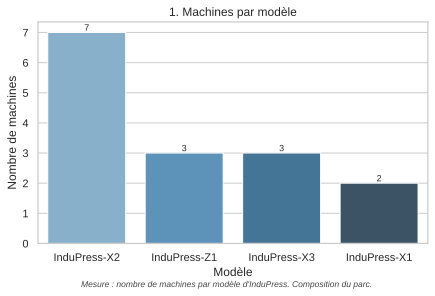

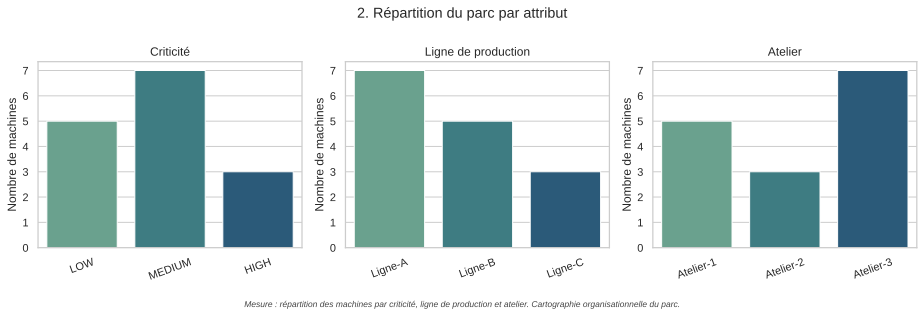

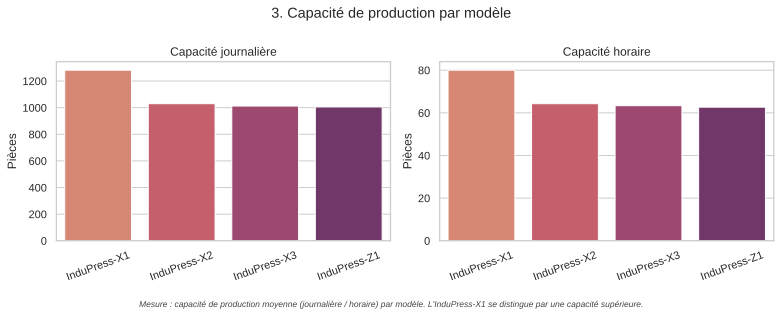

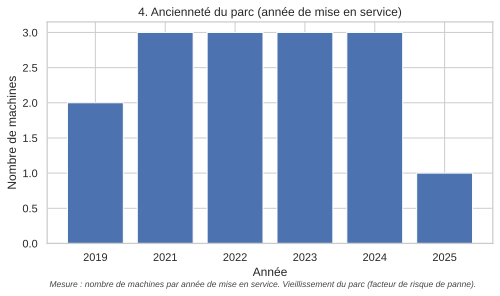

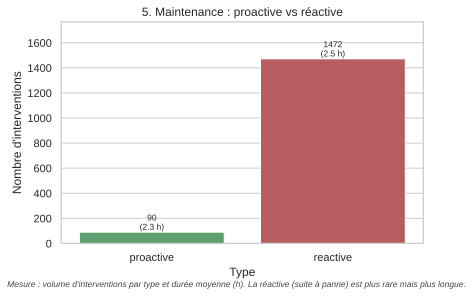

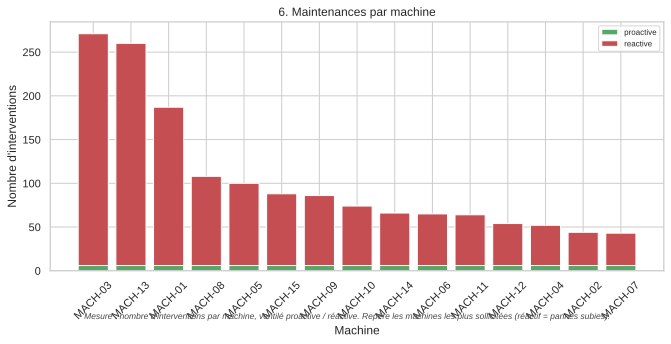

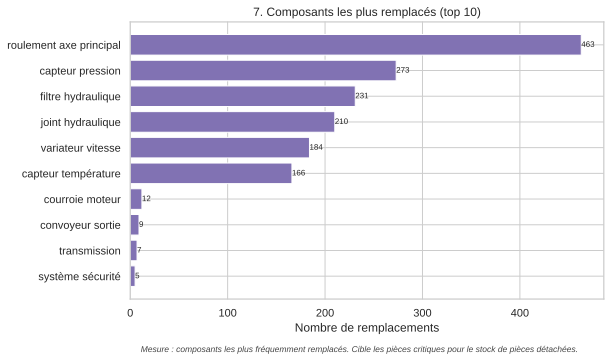

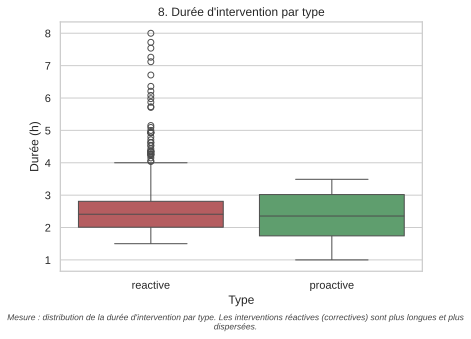

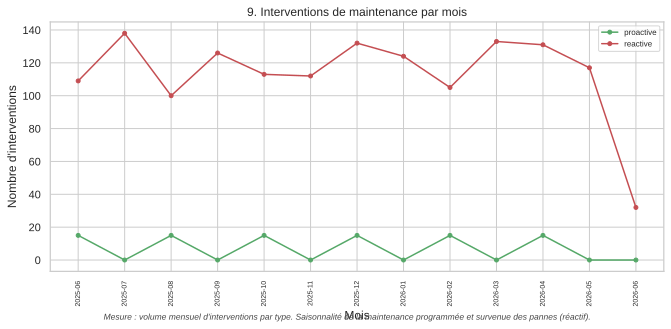

In [13]:
from IPython.display import SVG, display

from indusense import config

ref_run = sorted(p for p in config.ANALYSE_REFERENTIEL_DIR.glob("2*") if p.is_dir())[-1]
for fig_path in sorted((ref_run / "figures").glob("*.svg")):
    display(SVG(filename=str(fig_path)))


### 3. Tableaux de synthèse


In [14]:
machine, maintenance = ref_an.load_referentiel()
print('Répartition par modèle :')
display(ref_an.machine_distributions(machine)['model'])
print('Capacité moyenne par modèle :')
display(ref_an.capacity_by_model(machine).round(0))
summ = ref_an.maintenance_summary(maintenance)
print('Maintenance par type (durée en h) :')
display(summ['par_type'].round(2))
print('Top composants remplacés :')
summ['composants'].head(8)


Répartition par modèle :


model
InduPress-X2    7
InduPress-Z1    3
InduPress-X3    3
InduPress-X1    2
Name: count, dtype: int64

Capacité moyenne par modèle :


,max_daily_capacity,max_hourly_capacity_pieces
model,,
InduPress-X1,1282.0,80.0
InduPress-X2,1030.0,64.0
InduPress-X3,1012.0,63.0
InduPress-Z1,1005.0,63.0


Maintenance par type (durée en h) :


,count,mean,min,max
maintenance_type,,,,
proactive,90,2.34,1.0,3.49
reactive,1472,2.49,1.5,8.00


Top composants remplacés :


component
roulement axe principal    463
capteur pression           273
filtre hydraulique         231
joint hydraulique          210
variateur vitesse          184
capteur température        166
courroie moteur             12
convoyeur sortie             9
Name: count, dtype: int64

➡️ **Conclusions**

- **Parc** : 15 machines, 4 modèles (`InduPress-X2` majoritaire : 7 ; `X1` minoritaire :
  2 mais **plus capacitaire**). Criticité MEDIUM (7) / LOW (5) / HIGH (3) ; parc mis en
  service entre 2019 et 2025, toutes actives.
- **Maintenance** : **90 proactives** (préventif programmé) vs **25 réactives**
  (correctif sur panne), soit ~78 % / 22 %. La réactive est **~2× plus longue**
  (5,1 h vs 2,3 h) — le correctif coûte cher en immobilisation.
- **Composants** : les **capteurs (pression, température)** dominent les remplacements,
  cohérent avec les signaux d'incidents (`alarme_capteur`, `baisse_pression`).
- **Traçabilité** : les 25 maintenances réactives sont **toutes liées à un incident**
  (`related_incident_id`) ; `action_type` est redondant avec `maintenance_type`.
- **Enjeu** : la maintenance prédictive vise à **basculer du réactif (coûteux) vers le
  proactif ciblé** — d'où l'intérêt de relier télémétrie, incidents et maintenance.
